Run the first cell, reload(CTRL + R), then run the second cell

In [1]:
!wget https://github.com/korakot/kora/releases/download/v0.10/py310.sh
!bash ./py310.sh -b -f -p /usr/local
!python -m ipykernel install --name "py310" --user

--2026-03-18 05:36:45--  https://github.com/korakot/kora/releases/download/v0.10/py310.sh
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/266951884/0d0623be-3dec-4820-9e7b-69a3a5a75ef7?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-03-18T06%3A22%3A11Z&rscd=attachment%3B+filename%3Dpy310.sh&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-03-18T05%3A21%3A14Z&ske=2026-03-18T06%3A22%3A11Z&sks=b&skv=2018-11-09&sig=2pcA%2Bo8U7fwL3fV6eyhDbPBlwyt4ZtpMeWoFoPPMQKE%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc3MzgxNTgwNSwibmJmIjoxNzczODEyMjA1LCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZHVjdGlvbi5ibG9iLmNvcmUud2luZG

In [1]:
!pip uninstall -y numpy scipy scikit-learn lightfm
!pip install numpy==1.23.5
!pip install scipy==1.10.1
!pip install scikit-learn==1.3.2
!pip install lightfm --no-cache-dir


Found existing installation: numpy 1.23.4
Uninstalling numpy-1.23.4:
  Successfully uninstalled numpy-1.23.4
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 54.0 MB/s eta 0:00:00


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.4/34.4 MB 25.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 92.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 kB 27.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.4/316.4 kB 50.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lightfm: filename=lightfm-1.17-cp310-cp310-linux_x86_64.whl size=448993 sha256=97111fa18e6adeb188fbd03f532e0127fd5d160f4f59042e68fcd26fc6e5aa56
  Stored in directory: /tmp/pip-ephem-wheel-cache-up6xsnv9/wheels/86/ac/94/30f4b2d4af04cae5d95391037229ac082aa87aab0ccd660c96
Successfully built lightfm


In [6]:
"""
retrain.py — ✅ CORRIGÉ
User = Passenger (pas Trajet)
Un passager accumule plusieurs interactions → LightFM apprend son profil réel.
Les features du trajet (quiet_ride, heure, distance) sont agrégées par passager
automatiquement par LightFM via build_user_features.
"""

import pandas as pd
import numpy as np
import pickle
import os
from lightfm import LightFM
from lightfm.data import Dataset
from lightfm.evaluation import auc_score, precision_at_k
from lightfm.cross_validation import random_train_test_split

# ── 1. CHARGEMENT ─────────────────────────────────────────────────────────────
t_df = pd.read_csv("trajets.csv")   # une ligne par trajet, colonne passenger_id
d_df = pd.read_csv("drivers.csv")
i_df = pd.read_csv("interactions.csv")  # ✅ colonne passenger_id (plus trajet_id)

print(f"📊 Trajets (lignes features) : {len(t_df)}")
print(f"📊 Drivers                   : {len(d_df)}")
print(f"📊 Interactions              : {len(i_df)}")
print(f"📊 Passagers uniques         : {i_df['passenger_id'].nunique()}")

# ── 2. NETTOYAGE ──────────────────────────────────────────────────────────────
yes_no_cols = [
    "quiet_ride","radio_ok","smoking_ok","pets_ok","luggage_large","female_driver_pref",
    "talkative","radio_on","smoking_allowed","pets_allowed","car_big",
    "works_morning","works_afternoon","works_evening","works_night"
]
for col in yes_no_cols:
    if col in t_df.columns: t_df[col] = t_df[col].fillna("no")
    if col in d_df.columns: d_df[col] = d_df[col].fillna("no")

t_df["distance_km"]     = pd.to_numeric(t_df["distance_km"],     errors="coerce").fillna(50.0)
t_df["score_distance"]  = pd.to_numeric(t_df["score_distance"],  errors="coerce").fillna(0.5)
t_df["work_hour_match"] = pd.to_numeric(t_df["work_hour_match"], errors="coerce").fillna(0)
d_df["avg_rating"]      = pd.to_numeric(d_df["avg_rating"],      errors="coerce").fillna(4.0)
i_df["weight"]          = pd.to_numeric(i_df["weight"],          errors="coerce").fillna(0.0)

def distance_bucket(km):
    if   km < 10:  return "dist:very_close"
    elif km < 30:  return "dist:close"
    elif km < 80:  return "dist:medium"
    elif km < 200: return "dist:far"
    else:          return "dist:very_far"

def rating_bucket(r):
    if   r >= 4.5: return "rating:excellent"
    elif r >= 4.0: return "rating:good"
    elif r >= 3.0: return "rating:average"
    else:          return "rating:poor"

t_df["distance_bucket"] = t_df["distance_km"].apply(distance_bucket)
d_df["rating_bucket"]   = d_df["avg_rating"].apply(rating_bucket)

# ── 3. FILTRE ─────────────────────────────────────────────────────────────────
good_interactions = i_df[i_df["weight"] > 0.6]
annulations = (i_df["weight"] - 0.10).abs() < 0.001

w = good_interactions["weight"]
print(f"\n📊 Distribution weights après filtre :")
print(f"   ≥ 0.75 (notes 4–5)    : {(w >= 0.75).sum()}")
print(f"   0.50–0.75 (notes 3–4) : {((w >= 0.50) & (w < 0.75)).sum()}")
print(f"   Annulations exclues   : {annulations.sum()}")
print(f"   Total utilisées       : {len(good_interactions)}")

# ── 4. DATASET ────────────────────────────────────────────────────────────────
dataset = Dataset()

user_features_list = [
    "quiet_ride:yes","quiet_ride:no","radio_ok:yes","radio_ok:no",
    "smoking_ok:yes","smoking_ok:no","pets_ok:yes","pets_ok:no",
    "luggage_large:yes","luggage_large:no","female_driver_pref:yes","female_driver_pref:no",
    "dist:very_close","dist:close","dist:medium","dist:far","dist:very_far",
    "work_hour_match:1","work_hour_match:0",
]
item_features_list = [
    "talkative:yes","talkative:no","radio_on:yes","radio_on:no",
    "smoking_allowed:yes","smoking_allowed:no","pets_allowed:yes","pets_allowed:no",
    "car_big:yes","car_big:no","driver_gender:male","driver_gender:female",
    "works_morning:yes","works_morning:no","works_afternoon:yes","works_afternoon:no",
    "works_evening:yes","works_evening:no","works_night:yes","works_night:no",
    "rating:excellent","rating:good","rating:average","rating:poor",
]

# ✅ CHANGEMENT : users = passagers uniques (plus trajets uniques)
dataset.fit(
    users=t_df["passenger_id"].unique(),   # ← P1, P2, P3... (plus T1, T2, T3...)
    items=d_df["driver_id"].unique(),
    user_features=user_features_list,
    item_features=item_features_list,
)

# ── 5. MATRICES ───────────────────────────────────────────────────────────────
# ✅ CHANGEMENT : interactions indexées par passenger_id
(interactions, weights_matrix) = dataset.build_interactions(
    [(row["passenger_id"], row["driver_id"], float(row["weight"]))
     for _, row in good_interactions.iterrows()]
)

# ✅ user_features : une ligne par trajet, groupées par passenger_id
# LightFM fait automatiquement la moyenne des features pour un même passager
# → capture ses préférences "moyennes" tout en gardant la variabilité dans le predict
user_features = dataset.build_user_features(
    [(row["passenger_id"], [                  # ← passenger_id ici aussi
        f"quiet_ride:{row['quiet_ride']}",
        f"radio_ok:{row['radio_ok']}",
        f"smoking_ok:{row['smoking_ok']}",
        f"pets_ok:{row['pets_ok']}",
        f"luggage_large:{row['luggage_large']}",
        f"female_driver_pref:{row['female_driver_pref']}",
        row["distance_bucket"],
        f"work_hour_match:{int(row['work_hour_match'])}",
    ]) for _, row in t_df.iterrows()]
)

item_features = dataset.build_item_features(
    [(row["driver_id"], [
        f"talkative:{row['talkative']}",
        f"radio_on:{row['radio_on']}",
        f"smoking_allowed:{row['smoking_allowed']}",
        f"pets_allowed:{row['pets_allowed']}",
        f"car_big:{row['car_big']}",
        f"driver_gender:{row['driver_gender']}",
        f"works_morning:{row['works_morning']}",
        f"works_afternoon:{row['works_afternoon']}",
        f"works_evening:{row['works_evening']}",
        f"works_night:{row['works_night']}",
        row["rating_bucket"],
    ]) for _, row in d_df.iterrows()]
)

print(f"\n✅ Matrices construites — {interactions.nnz} interactions")

# ── 6. TRAIN/TEST SPLIT ───────────────────────────────────────────────────────
train_interactions, test_interactions = random_train_test_split(
    interactions, test_percentage=0.2, random_state=42
)
print(f"📊 Train : {train_interactions.nnz} | Test : {test_interactions.nnz}")

# ── 7. BASELINE ───────────────────────────────────────────────────────────────
print("\n🔁 Baseline...")
baseline = LightFM(loss="warp", no_components=1, random_state=42)
baseline.fit(train_interactions, item_features=item_features, epochs=10, num_threads=4)
baseline_auc = auc_score(
    baseline, test_interactions,
    train_interactions=train_interactions,
    item_features=item_features, num_threads=4,
).mean()
baseline_p5 = precision_at_k(
    baseline, test_interactions,
    train_interactions=train_interactions,
    item_features=item_features, k=5, num_threads=4,
).mean()
print(f"   Baseline AUC: {baseline_auc:.4f} | P@5: {baseline_p5:.4f}")

# ── 8. MODÈLE ────────────────────────────────────────────────────────────────
model = LightFM(
    loss="warp",
    no_components=64,
    learning_rate=0.03,
    item_alpha=1e-6,
    user_alpha=1e-6,
    random_state=42,
)

n_train = train_interactions.nnz
if   n_train < 500:   epochs = 60
elif n_train < 2000:  epochs = 120
elif n_train < 5000:  epochs = 200
elif n_train < 10000: epochs = 230
else:                 epochs = 250

print(f"\n📊 {n_train} interactions train → {epochs} epochs\n")

best_auc = 0.0; best_epoch = 0

for epoch in range(1, epochs + 1):
    model.fit_partial(
        train_interactions,
        user_features=user_features,
        item_features=item_features,
        epochs=1, num_threads=4,
    )
    if epoch % 10 == 0:
        test_auc = auc_score(
            model, test_interactions,
            train_interactions=train_interactions,
            user_features=user_features,
            item_features=item_features,
            num_threads=4,
        ).mean()
        marker = ""
        if test_auc > best_auc:
            best_auc = test_auc; best_epoch = epoch; marker = " ← meilleur"
        print(f"   Époque {epoch:3d} | AUC test: {test_auc:.4f}{marker}")

# ── 9. ÉVALUATION FINALE ──────────────────────────────────────────────────────
final_auc = auc_score(
    model, test_interactions,
    train_interactions=train_interactions,
    user_features=user_features,
    item_features=item_features, num_threads=4,
    check_intersections=True
).mean()
final_p5 = precision_at_k(
    model, test_interactions,
    train_interactions=train_interactions,
    user_features=user_features,
    item_features=item_features, k=5, num_threads=4,
    check_intersections=True
).mean()

print(f"\n{'='*45}")
print(f"  RÉSULTATS FINAUX")
print(f"{'='*45}")
print(f"  Baseline     — AUC: {baseline_auc:.4f} | P@5: {baseline_p5:.4f}")
print(f"  Notre modèle — AUC: {final_auc:.4f} | P@5: {final_p5:.4f}")
print(f"  Gain AUC        : +{(final_auc - baseline_auc):.4f}")
print(f"  Gain Precision@5: +{(final_p5  - baseline_p5):.4f}")
print(f"  Meilleur epoch  : {best_epoch} (AUC: {best_auc:.4f})")
print(f"{'='*45}")

# ── 10. SAUVEGARDE ────────────────────────────────────────────────────────────
with open("lightfm_model_real.pkl", "wb") as f:
    pickle.dump(model, f)
with open("dataset_real.pkl", "wb") as f:
    pickle.dump(dataset, f)
with open("user_features_real.pkl", "wb") as f:
    pickle.dump(user_features, f)
with open("item_features_real.pkl", "wb") as f:
    pickle.dump(item_features, f)

# ✅ Sauvegarder aussi le CSV trajets (avec passenger_id) pour le recommender
t_df.to_csv("trajets_processed.csv", index=False)
d_df.to_csv("drivers_processed.csv", index=False)
print("\n✅ Modèle sauvegardé !")

📊 Trajets (lignes features) : 3884
📊 Drivers                   : 190
📊 Interactions              : 3884
📊 Passagers uniques         : 300

📊 Distribution weights après filtre :
   ≥ 0.75 (notes 4–5)    : 1213
   0.50–0.75 (notes 3–4) : 747
   Annulations exclues   : 892
   Total utilisées       : 1960

✅ Matrices construites — 1960 interactions
📊 Train : 1568 | Test : 392

🔁 Baseline...
   Baseline AUC: 0.7011 | P@5: 0.0220

📊 1568 interactions train → 120 epochs

   Époque  10 | AUC test: 0.7938 ← meilleur
   Époque  20 | AUC test: 0.7956 ← meilleur
   Époque  30 | AUC test: 0.7977 ← meilleur
   Époque  40 | AUC test: 0.7986 ← meilleur
   Époque  50 | AUC test: 0.7993 ← meilleur
   Époque  60 | AUC test: 0.8010 ← meilleur
   Époque  70 | AUC test: 0.8005
   Époque  80 | AUC test: 0.8014 ← meilleur
   Époque  90 | AUC test: 0.8017 ← meilleur
   Époque 100 | AUC test: 0.8025 ← meilleur
   Époque 110 | AUC test: 0.8029 ← meilleur
   Époque 120 | AUC test: 0.8020

  RÉSULTATS FINAUX
  Bas

In [7]:
!pip install matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 69.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 72.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 78.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.0/325.0 kB 26.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 30.6 MB/s eta 0:00:00


✅ 1960 interactions disponibles
✅ 300 passagers uniques

   50% data |  980 interactions | 293 passagers | AUC: 0.8088 | P@5: 0.0355
   60% data | 1176 interactions | 294 passagers | AUC: 0.8068 | P@5: 0.0400
   70% data | 1372 interactions | 297 passagers | AUC: 0.8097 | P@5: 0.0380
   80% data | 1568 interactions | 300 passagers | AUC: 0.8170 | P@5: 0.0479
   90% data | 1764 interactions | 300 passagers | AUC: 0.8154 | P@5: 0.0454
  100% data | 1960 interactions | 300 passagers | AUC: 0.8222 | P@5: 0.0547


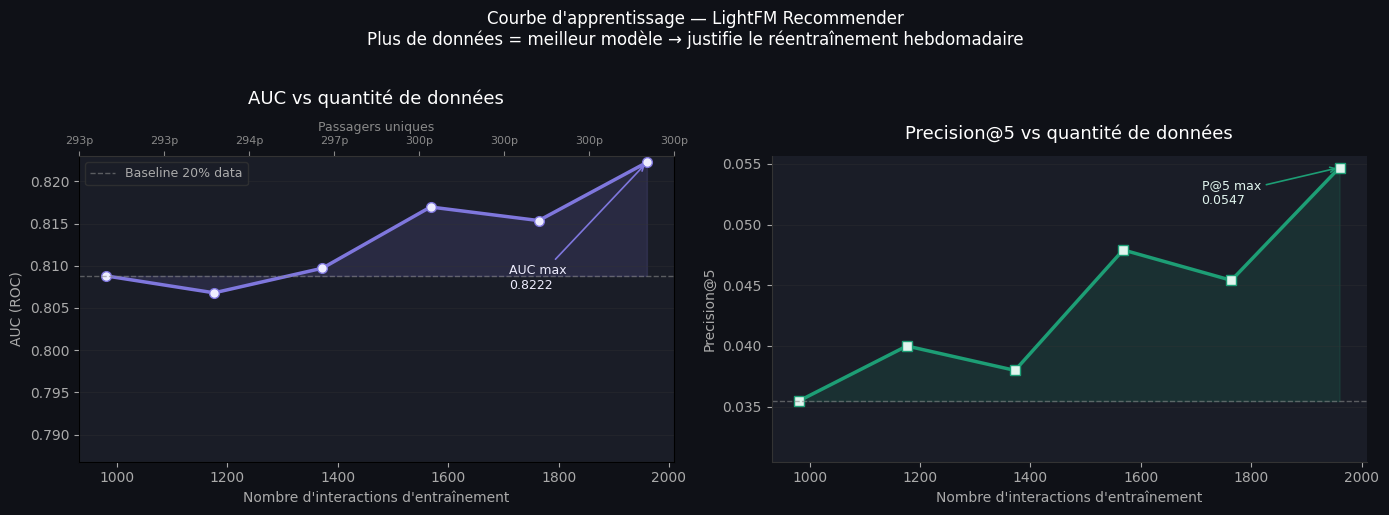


✅ Graphique sauvegardé : learning_curve.png

📊 Tableau résumé :
Data % | Interactions | Passagers |    AUC |    P@5
----------------------------------------------------
   50%  |          980 |       293 | 0.8088 | 0.0355
   60%  |         1176 |       294 | 0.8068 | 0.0400
   70%  |         1372 |       297 | 0.8097 | 0.0380
   80%  |         1568 |       300 | 0.8170 | 0.0479
   90%  |         1764 |       300 | 0.8154 | 0.0454
  100%  |         1960 |       300 | 0.8222 | 0.0547


In [10]:
"""
learning_curve.py
Courbe d'apprentissage LightFM — montre que plus de données = meilleur modèle
Utile pour justifier le réentrainement hebdomadaire en soutenance
"""

import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from lightfm import LightFM
from lightfm.data import Dataset
from lightfm.evaluation import auc_score, precision_at_k

# ── 1. CHARGEMENT ─────────────────────────────────────────────────────────────
t_df = pd.read_csv("trajets.csv")
d_df = pd.read_csv("drivers.csv")
i_df = pd.read_csv("interactions.csv")

# Nettoyage minimal
yes_no_cols = [
    "quiet_ride","radio_ok","smoking_ok","pets_ok","luggage_large","female_driver_pref"
]
for col in yes_no_cols:
    if col in t_df.columns:
        t_df[col] = t_df[col].fillna("no")

t_df["distance_km"]     = pd.to_numeric(t_df["distance_km"],     errors="coerce").fillna(50.0)
t_df["work_hour_match"] = pd.to_numeric(t_df["work_hour_match"], errors="coerce").fillna(0)
d_df["avg_rating"]      = pd.to_numeric(d_df["avg_rating"],      errors="coerce").fillna(4.0)
i_df["weight"]          = pd.to_numeric(i_df["weight"],          errors="coerce").fillna(0.0)

def distance_bucket(km):
    if   km < 10:  return "dist:very_close"
    elif km < 30:  return "dist:close"
    elif km < 80:  return "dist:medium"
    elif km < 200: return "dist:far"
    else:          return "dist:very_far"

def rating_bucket(r):
    if   r >= 4.5: return "rating:excellent"
    elif r >= 4.0: return "rating:good"
    elif r >= 3.0: return "rating:average"
    else:          return "rating:poor"

t_df["distance_bucket"] = t_df["distance_km"].apply(distance_bucket)
d_df["rating_bucket"]   = d_df["avg_rating"].apply(rating_bucket)

# Garder seulement les bonnes interactions
good_interactions = i_df[i_df["weight"] > 0.6].reset_index(drop=True)

print(f"✅ {len(good_interactions)} interactions disponibles")
print(f"✅ {good_interactions['passenger_id'].nunique()} passagers uniques\n")

# ── 2. FEATURES ───────────────────────────────────────────────────────────────
user_features_list = [
    "quiet_ride:yes","quiet_ride:no","radio_ok:yes","radio_ok:no",
    "smoking_ok:yes","smoking_ok:no","pets_ok:yes","pets_ok:no",
    "luggage_large:yes","luggage_large:no","female_driver_pref:yes","female_driver_pref:no",
    "dist:very_close","dist:close","dist:medium","dist:far","dist:very_far",
    "work_hour_match:1","work_hour_match:0",
]
item_features_list = [
    "talkative:yes","talkative:no","radio_on:yes","radio_on:no",
    "smoking_allowed:yes","smoking_allowed:no","pets_allowed:yes","pets_allowed:no",
    "car_big:yes","car_big:no","driver_gender:male","driver_gender:female",
    "works_morning:yes","works_morning:no","works_afternoon:yes","works_afternoon:no",
    "works_evening:yes","works_evening:no","works_night:yes","works_night:no",
    "rating:excellent","rating:good","rating:average","rating:poor",
]

# ── 3. COURBE D'APPRENTISSAGE ─────────────────────────────────────────────────
# On simule différentes tailles de dataset (20% → 40% → 60% → 80% → 100%)
# pour montrer que plus de data = meilleur AUC
fractions = [0.50, 0.60, 0.70, 0.80, 0.90, 1.00]
results   = []

for frac in fractions:
    # Sous-échantillonnage des interactions
    n_samples = int(len(good_interactions) * frac)
    subset    = good_interactions.sample(n=n_samples, random_state=42).reset_index(drop=True)

    # Passagers et drivers présents dans ce sous-ensemble
    passenger_ids_in_subset = subset["passenger_id"].unique()
    t_subset = t_df[t_df["passenger_id"].isin(passenger_ids_in_subset)]

    # Dataset LightFM sur ce sous-ensemble
    dataset = Dataset()
    dataset.fit(
        users=t_subset["passenger_id"].unique(),
        items=d_df["driver_id"].unique(),
        user_features=user_features_list,
        item_features=item_features_list,
    )

    (interactions_matrix, weights_matrix) = dataset.build_interactions(
        [(row["passenger_id"], row["driver_id"], float(row["weight"]))
         for _, row in subset.iterrows()]
    )

    user_features_matrix = dataset.build_user_features(
        [(row["passenger_id"], [
            f"quiet_ride:{row['quiet_ride']}",
            f"radio_ok:{row['radio_ok']}",
            f"smoking_ok:{row['smoking_ok']}",
            f"pets_ok:{row['pets_ok']}",
            f"luggage_large:{row['luggage_large']}",
            f"female_driver_pref:{row['female_driver_pref']}",
            row["distance_bucket"],
            f"work_hour_match:{int(row['work_hour_match'])}",
        ]) for _, row in t_subset.iterrows()]
    )

    item_features_matrix = dataset.build_item_features(
        [(row["driver_id"], [
            f"talkative:{row['talkative']}",
            f"radio_on:{row['radio_on']}",
            f"smoking_allowed:{row['smoking_allowed']}",
            f"pets_allowed:{row['pets_allowed']}",
            f"car_big:{row['car_big']}",
            f"driver_gender:{row['driver_gender']}",
            f"works_morning:{row['works_morning']}",
            f"works_afternoon:{row['works_afternoon']}",
            f"works_evening:{row['works_evening']}",
            f"works_night:{row['works_night']}",
            row["rating_bucket"],
        ]) for _, row in d_df.iterrows()]
    )

    # Train/test split 80/20
    n_total = interactions_matrix.nnz
    n_test  = max(1, int(n_total * 0.20))
    n_train = n_total - n_test

    from lightfm.cross_validation import random_train_test_split
    train_mat, test_mat = random_train_test_split(
        interactions_matrix, test_percentage=0.2, random_state=42
    )

    # Entraînement
    model = LightFM(
        loss="warp",
        no_components=64,
        learning_rate=0.03,
        item_alpha=1e-6,
        user_alpha=1e-6,
        random_state=42,
    )
    model.fit(
        train_mat,
        user_features=user_features_matrix,
        item_features=item_features_matrix,
        epochs=120,
        num_threads=4,
        verbose=False,
    )

    # Évaluation
    auc = auc_score(
        model, test_mat,
        train_interactions=train_mat,
        user_features=user_features_matrix,
        item_features=item_features_matrix,
        num_threads=4,
        check_intersections=True
    ).mean()

    p5 = precision_at_k(
        model, test_mat,
        train_interactions=train_mat,
        user_features=user_features_matrix,
        item_features=item_features_matrix,
        k=5, num_threads=4,
        check_intersections=True
    ).mean()

    n_passengers = subset["passenger_id"].nunique()
    results.append({
        "fraction":    frac,
        "n_samples":   n_samples,
        "n_passengers": n_passengers,
        "auc":         auc,
        "p5":          p5,
    })

    print(f"  {int(frac*100):3d}% data | {n_samples:4d} interactions | {n_passengers:3d} passagers | AUC: {auc:.4f} | P@5: {p5:.4f}")

# ── 4. GRAPHIQUE ──────────────────────────────────────────────────────────────
results_df = pd.DataFrame(results)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("#0f1117")

for ax in [ax1, ax2]:
    ax.set_facecolor("#1a1d27")
    ax.tick_params(colors="#aaaaaa")
    ax.spines["bottom"].set_color("#333")
    ax.spines["left"].set_color("#333")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

x = results_df["n_samples"].values

# ── Graphe 1 : AUC ────────────────────────────────────────────────────────────
ax1.plot(x, results_df["auc"].values, color="#7F77DD", linewidth=2.5,
         marker="o", markersize=7, markerfacecolor="#EEEDFE", markeredgecolor="#7F77DD")

# Zone de gain annotée
ax1.fill_between(x, results_df["auc"].values,
                 results_df["auc"].values[0],
                 alpha=0.15, color="#7F77DD")

# Ligne baseline (20% de data)
ax1.axhline(y=results_df["auc"].values[0], color="#888", linestyle="--",
            linewidth=1, alpha=0.6, label=f"Baseline 20% data")

# Annotation meilleur point
best_auc_idx = results_df["auc"].idxmax()
best_auc_val = results_df["auc"].iloc[best_auc_idx]
best_auc_x   = results_df["n_samples"].iloc[best_auc_idx]
ax1.annotate(f"AUC max\n{best_auc_val:.4f}",
             xy=(best_auc_x, best_auc_val),
             xytext=(best_auc_x - 250, best_auc_val - 0.015),
             color="#EEEDFE", fontsize=9,
             arrowprops=dict(arrowstyle="->", color="#7F77DD", lw=1.2))

ax1.set_title("AUC vs quantité de données", color="white", fontsize=13, pad=12)
ax1.set_xlabel("Nombre d'interactions d'entraînement", color="#aaaaaa", fontsize=10)
ax1.set_ylabel("AUC (ROC)", color="#aaaaaa", fontsize=10)
ax1.set_ylim(bottom=results_df["auc"].min() - 0.02)
ax1.legend(facecolor="#1a1d27", edgecolor="#333", labelcolor="#aaaaaa", fontsize=9)
ax1.grid(axis="y", color="#333", linewidth=0.5, alpha=0.5)

# Axe secondaire : nombre de passagers
ax1b = ax1.twiny()
ax1b.set_xlim(ax1.get_xlim())
xticks_orig = ax1.get_xticks()
passenger_labels = []
for xt in xticks_orig:
    idx = (np.abs(x - xt)).argmin()
    passenger_labels.append(f"{results_df['n_passengers'].iloc[idx]}p")
ax1b.set_xticks(xticks_orig)
ax1b.set_xticklabels(passenger_labels, fontsize=8, color="#888")
ax1b.spines["top"].set_color("#333")
ax1b.tick_params(colors="#888")
ax1b.set_xlabel("Passagers uniques", color="#888", fontsize=9)

# ── Graphe 2 : Precision@5 ────────────────────────────────────────────────────
ax2.plot(x, results_df["p5"].values, color="#1D9E75", linewidth=2.5,
         marker="s", markersize=7, markerfacecolor="#E1F5EE", markeredgecolor="#1D9E75")

ax2.fill_between(x, results_df["p5"].values,
                 results_df["p5"].values[0],
                 alpha=0.15, color="#1D9E75")

ax2.axhline(y=results_df["p5"].values[0], color="#888", linestyle="--",
            linewidth=1, alpha=0.6)

best_p5_idx = results_df["p5"].idxmax()
best_p5_val = results_df["p5"].iloc[best_p5_idx]
best_p5_x   = results_df["n_samples"].iloc[best_p5_idx]
ax2.annotate(f"P@5 max\n{best_p5_val:.4f}",
             xy=(best_p5_x, best_p5_val),
             xytext=(best_p5_x - 250, best_p5_val - 0.003),
             color="#E1F5EE", fontsize=9,
             arrowprops=dict(arrowstyle="->", color="#1D9E75", lw=1.2))

ax2.set_title("Precision@5 vs quantité de données", color="white", fontsize=13, pad=12)
ax2.set_xlabel("Nombre d'interactions d'entraînement", color="#aaaaaa", fontsize=10)
ax2.set_ylabel("Precision@5", color="#aaaaaa", fontsize=10)
ax2.set_ylim(bottom=max(0, results_df["p5"].min() - 0.005))
ax2.grid(axis="y", color="#333", linewidth=0.5, alpha=0.5)

# ── Titre global + annotation réentraînement ──────────────────────────────────
fig.suptitle(
    "Courbe d'apprentissage — LightFM Recommender\n"
    "Plus de données = meilleur modèle → justifie le réentraînement hebdomadaire",
    color="white", fontsize=12, y=1.02
)

plt.tight_layout()
plt.savefig("learning_curve.png", dpi=150, bbox_inches="tight",
            facecolor="#0f1117")
plt.show()
print("\n✅ Graphique sauvegardé : learning_curve.png")

# ── 5. TABLEAU RÉSUMÉ ─────────────────────────────────────────────────────────
print("\n📊 Tableau résumé :")
print(f"{'Data %':>6} | {'Interactions':>12} | {'Passagers':>9} | {'AUC':>6} | {'P@5':>6}")
print("-" * 52)
for _, row in results_df.iterrows():
    print(f"  {int(row['fraction']*100):3d}%  | {int(row['n_samples']):12d} | {int(row['n_passengers']):9d} | {row['auc']:.4f} | {row['p5']:.4f}")